In [1]:
import os
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the plots look nice
sns.set_theme(style="whitegrid")

In [2]:
# Point this to your specific directory
directory_path = "runs/qwen35_9b_lora_newprompt/eval_results_og/"
json_files = glob.glob(os.path.join(directory_path, "*.json"))

data = []

for file_path in json_files:
    filename = os.path.basename(file_path)
    
    if "base" in filename:
        step = 0
    elif "final" in filename:
        step = 99999 
    else:
        try:
            step = int(filename.split("-")[1].split(".")[0])
        except:
            step = -1

    with open(file_path, 'r', encoding='utf-8') as f:
        content = json.load(f)
        
    metrics = content.get("metrics", {})
    per_field_acc = metrics.get("per_field_accuracy", {})
    per_field_metrics = metrics.get("per_field_metrics", {})
    hazard_binary = metrics.get("hazard_present_binary", {})
    
    # Helper to safely get macro_f1
    def get_f1(field):
        return per_field_metrics.get(field, {}).get("macro_f1", 0)
    
    # Helper to sum False Positives across all classes in a field
    def get_fp(field):
        labels = per_field_metrics.get(field, {}).get("labels", {})
        return sum(label_info.get("fp", 0) for label_info in labels.values())

    row = {
        "checkpoint": filename.replace(".json", ""),
        "step": step,
        
        # --- OVERALL METRICS ---
        "exact_match_accuracy": metrics.get("exact_match_accuracy", 0),
        "hazard_f1": hazard_binary.get("f1", 0),
        "hazard_recall": hazard_binary.get("recall", 0), 
        "samples_per_sec": metrics.get("samples_per_sec", 0),
        
        # --- PER-FIELD ACCURACY ---
        "hazard_label_acc": per_field_acc.get("hazard_label", 0),
        "hazard_present_acc": per_field_acc.get("hazard_present", 0),
        "zone_relation_acc": per_field_acc.get("zone_relation", 0),
        "object_state_acc": per_field_acc.get("object_state", 0),
        "object_direction_acc": per_field_acc.get("object_direction", 0),
        
        # --- PER-FIELD MACRO F1 ---
        "hazard_label_f1": get_f1("hazard_label"),
        "hazard_present_f1": get_f1("hazard_present"),
        "zone_relation_f1": get_f1("zone_relation"),
        "object_state_f1": get_f1("object_state"),
        "object_direction_f1": get_f1("object_direction"),
        
        # --- PER-FIELD FALSE POSITIVES ---
        "hazard_label_fp": get_fp("hazard_label"),
        "hazard_present_fp": get_fp("hazard_present"),
        "zone_relation_fp": get_fp("zone_relation"),
        "object_state_fp": get_fp("object_state"),
        "object_direction_fp": get_fp("object_direction")
    }
    data.append(row)

# Create DataFrame and sort it chronologically
df = pd.DataFrame(data)
df = df.sort_values("step").reset_index(drop=True)

# Preview the first few rows
df.head()

,checkpoint,step,exact_match_accuracy,hazard_f1,hazard_recall,samples_per_sec,hazard_label_acc,hazard_present_acc,zone_relation_acc,object_state_acc,...,hazard_label_f1,hazard_present_f1,zone_relation_f1,object_state_f1,object_direction_f1,hazard_label_fp,hazard_present_fp,zone_relation_fp,object_state_fp,object_direction_fp
0,all_metrics,-1,0.0000,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0,0,0
1,base_pretrained,0,0.3309,0.0,0.0,0.1570,0.8676,0.8676,0.3309,0.4485,...,0.4646,0.4646,0.1818,0.4223,0.2780,18,18,91,75,77
2,checkpoint-54,54,0.7574,0.0,0.0,0.1743,0.8676,0.8676,0.8382,0.8382,...,0.4646,0.4646,0.7018,0.7018,0.3012,18,18,22,22,33
3,checkpoint-108,108,0.8603,0.0,0.0,0.1732,0.8676,0.8676,0.9191,0.9926,...,0.4646,0.4646,0.5370,0.9844,0.3319,18,18,11,1,19
4,checkpoint-162,162,0.2574,0.0,0.0,0.1839,0.8676,0.8676,0.3676,0.3897,...,0.4646,0.4646,0.4555,0.3800,0.1525,18,18,86,83,101


0 [-0.48736351  0.32102184]
14 [0.42317808 0.39735742]
28 [ 0.89745571 -0.9391663 ]
42 [-0.08607941 -0.87050198]
56 [0.20076183 0.39286208]
1 [ 0.28071127 -0.30991027]
15 [0.26333344 0.03323108]
30 [0.42365594 0.81121093]
44 [0.96891884 0.01317766]
2 [-0.54254819  0.22502756]
16 [-0.24199902  0.61579281]
3 [-0.06242824  0.50081698]
17 [0.38772949 0.21438126]
4 [ 0.65080822 -0.52119115]
18 [-0.57008925 -0.5230686 ]
47 [-0.57147625  0.48594278]
61 [-0.18946451 -0.58098611]
5 [0.3249507  0.42575816]
19 [ 0.85900622 -0.69156704]
6 [-0.65225545 -0.20295872]
20 [0.91851628 0.14640803]
34 [-0.35426294 -0.89131526]
7 [0.06863836 0.20770246]
21 [ 0.21414283 -0.14861584]
8 [-0.45354431  0.78041034]
22 [0.2106579  0.42817399]
36 [-0.908706    0.20451695]
50 [ 0.89980161 -0.87033615]
64 [-0.81564188 -0.87981115]
9 [-0.2763862   0.50321401]
23 [-0.96498572 -0.83105934]
37 [0.68622273 0.07719858]
65 [-0.08127166  0.83107075]
10 [-0.93605951  0.66500574]
24 [-0.35366714  0.595739  ]
38 [-0.9553028   

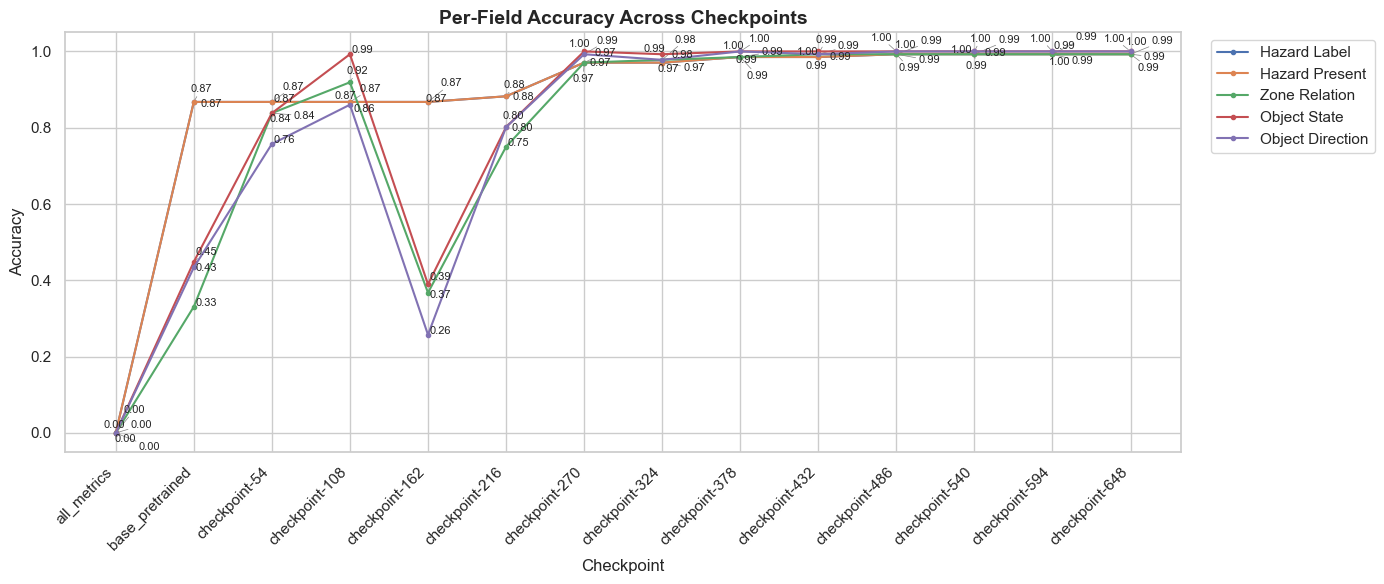

In [4]:
import matplotlib.pyplot as plt

# ... (assuming df is defined above this snippet) ...

fields_to_plot = [
    "hazard_label_acc", 
    "hazard_present_acc", 
    "zone_relation_acc", 
    "object_state_acc", 
    "object_direction_acc"
]

plt.figure(figsize=(14, 6))

texts = [] # We need a list to collect all the text objects

for field in fields_to_plot:
    clean_label = field.replace("_acc", "").replace("_", " ").title()
    plt.plot(df["checkpoint"], df[field], marker='.', label=clean_label, linewidth=1.5)
    
    # Create the text objects but don't finalize their positions yet
    for x, y in zip(df["checkpoint"], df[field]):
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# Let adjustText do the heavy lifting to prevent overlaps
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Accuracy Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [ 0.12533788 -0.29043901]
14 [ 0.34202673 -0.46297865]
28 [ 0.92829817 -0.85411723]
42 [-0.88623196 -0.17077714]
56 [0.57964268 0.14005827]
1 [ 0.31266822 -0.79691746]
15 [0.52446827 0.82740002]
2 [0.13860911 0.37828283]
16 [-0.17587882  0.74574895]
30 [-0.97456194 -0.76744069]
44 [0.50680464 0.95148145]
3 [ 0.77484799 -0.68144434]
17 [-0.68645817 -0.56850154]
4 [0.75597695 0.02489187]
18 [-0.99796231 -0.6489038 ]
5 [-0.26699569  0.33693813]
19 [ 0.97566909 -0.35869747]
6 [-0.03700276  0.9529306 ]
20 [-0.22952449  0.76920282]
35 [ 0.02745054 -0.76089826]
63 [-0.64310035  0.32570939]
7 [ 0.63835823 -0.97908513]
21 [ 0.34873203 -0.77866592]
8 [ 0.81044447 -0.40813689]
22 [-0.77547299  0.94404556]
50 [ 0.98973171 -0.37875693]
64 [-0.24021658 -0.16849221]
37 [-0.0293813   0.47032228]
65 [0.3649602  0.18692943]
9 [-0.5552462  -0.54025439]
23 [0.00751821 0.629922  ]
10 [0.19527574 0.19857574]
24 [0.41203947 0.3798772 ]
52 [0.20873382 0.48291503]
66 [-0.50911238  0.06792578]
11 [-0.59252346

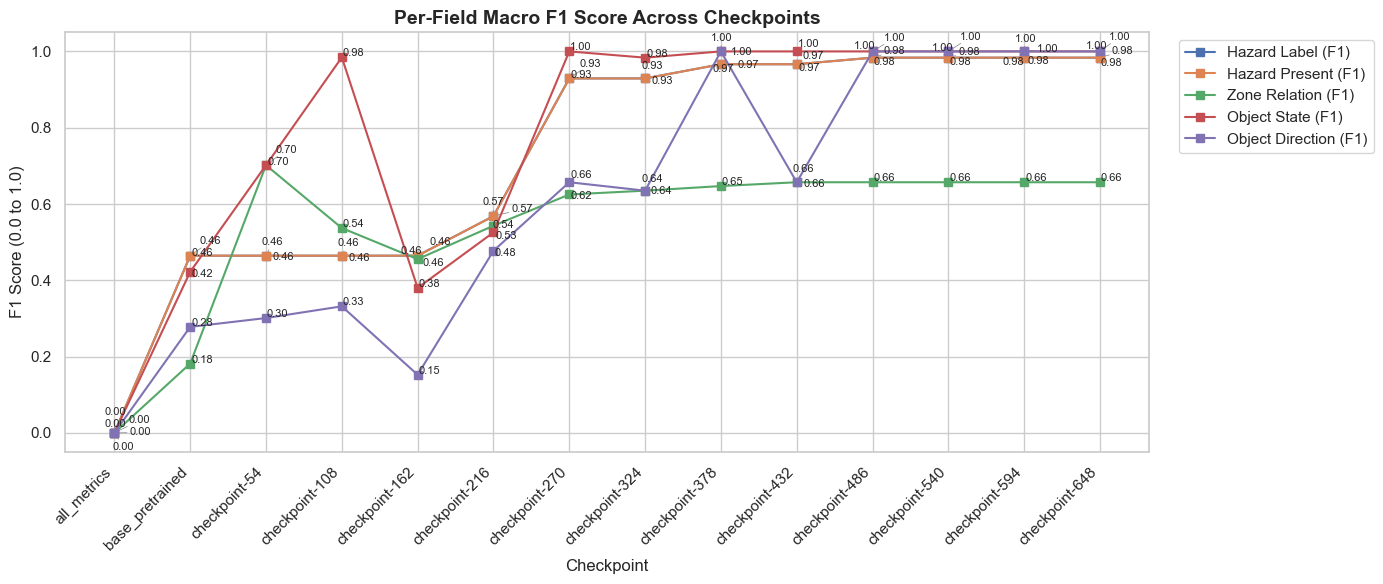

In [5]:
fields_to_plot_f1 = [
    "hazard_label_f1", 
    "hazard_present_f1", 
    "zone_relation_f1", 
    "object_state_f1", 
    "object_direction_f1"
]

plt.figure(figsize=(14, 6))

texts = [] # List to collect all the text objects

for field in fields_to_plot_f1:
    clean_label = field.replace("_f1", "").replace("_", " ").title() + " (F1)"
    plt.plot(df["checkpoint"], df[field], marker='s', label=clean_label, linewidth=1.5)
    
    # Create the text objects but don't finalize their positions yet
    for x, y in zip(df["checkpoint"], df[field]):
        texts.append(plt.text(x, y, f'{y:.2f}', fontsize=8))

# Let adjustText do the heavy lifting to prevent overlaps
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Macro F1 Score Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("F1 Score (0.0 to 1.0)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()

0 [ 0.16537727 -0.96508966]
14 [-0.24197516 -0.87340259]
28 [ 0.06002439 -0.50942594]
42 [-0.60006413  0.72797613]
56 [ 0.24739604 -0.94864899]
1 [ 0.01467065 -0.07116215]
15 [-0.84535392  0.33638348]
2 [-0.45737109  0.36661648]
16 [0.81435773 0.96836164]
30 [-0.22146649 -0.42789452]
44 [ 0.47170009 -0.59452743]
3 [-0.43860454 -0.16368765]
17 [ 0.48778063 -0.30041395]
4 [-0.52059743 -0.07478246]
18 [-0.10538894 -0.96609105]
5 [-0.64987842  0.98683859]
19 [0.53036037 0.63262307]
47 [-0.17457884  0.9190749 ]
61 [-0.11929164 -0.019404  ]
6 [-0.83943054  0.82511828]
20 [-0.36385965 -0.75613546]
34 [0.63738138 0.79219278]
7 [0.12919514 0.70325576]
21 [-0.16496512 -0.57563552]
8 [0.36851542 0.58667856]
22 [-0.60098623 -0.95206167]
36 [-0.42116658  0.44993216]
50 [0.41552229 0.93664494]
64 [ 0.98868817 -0.13216313]
37 [-0.00236031 -0.88619563]
65 [-0.1359361  -0.69595198]
9 [0.84744415 0.54686553]
23 [-0.5879495  -0.08375311]
52 [0.19728641 0.51791696]
66 [-0.58571264  0.97991306]
10 [-0.2452

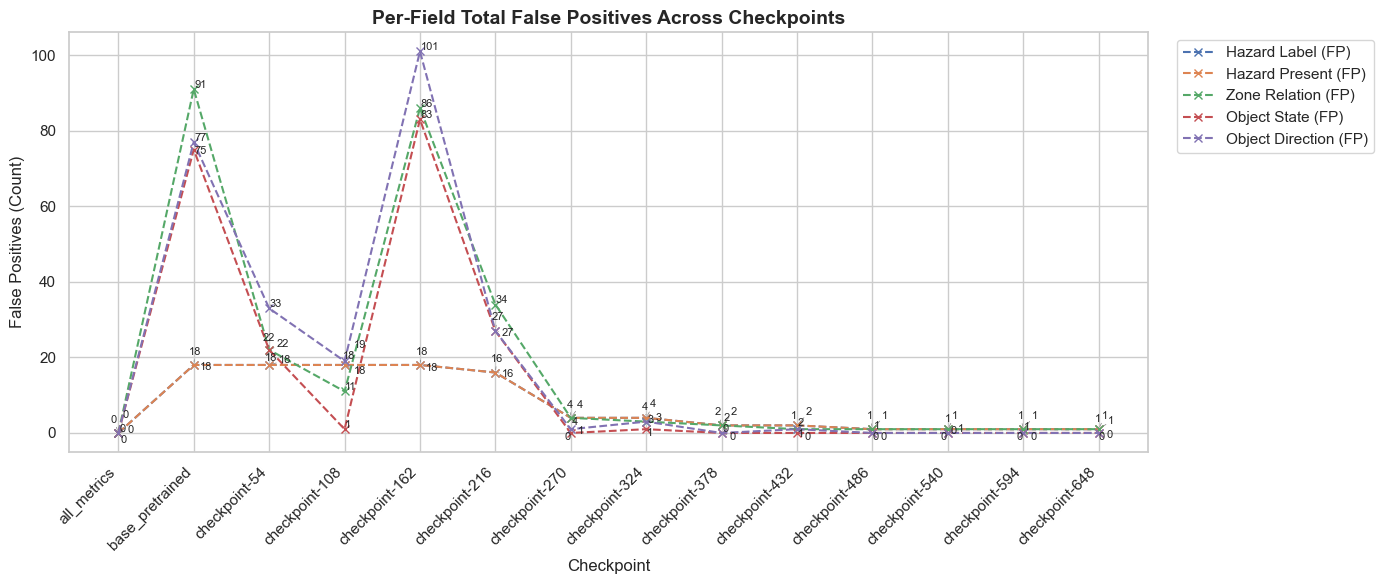

In [6]:
fields_to_plot_fp = [
    "hazard_label_fp", 
    "hazard_present_fp", 
    "zone_relation_fp", 
    "object_state_fp", 
    "object_direction_fp"
]

plt.figure(figsize=(14, 6))
texts = [] # List to collect text objects for automatic adjustment

for field in fields_to_plot_fp:
    # Formatting label for the legend
    clean_label = field.replace("_fp", "").replace("_", " ").title() + " (FP)"
    
    # Plotting with 'x' markers and dashed lines as requested
    plt.plot(df["checkpoint"], df[field], marker='x', label=clean_label, linewidth=1.5, linestyle='--')
    
    # Adding data labels to the list
    for x, y in zip(df["checkpoint"], df[field]):
        # Using int(y) for clean count labels
        texts.append(plt.text(x, y, f'{int(y)}', fontsize=8))

# This handles the magic of moving overlapping numbers
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Per-Field Total False Positives Across Checkpoints", fontsize=14, fontweight='bold')
plt.xlabel("Checkpoint", fontsize=12)
plt.ylabel("False Positives (Count)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Place legend outside to the right
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
plt.tight_layout()
plt.show()